# 10. Threshold optimization

**Question: how much of the achievable cost reduction comes from the decision rule
rather than the model?**

This is the central notebook of the study.

Everything up to here has been about producing a good score. This notebook is about what
to do with it — and on this problem, that second step is worth more than most of the
first. Moving the threshold from `0.5` to its cost-optimal value routinely cuts the bill
by an order of magnitude, on an *unchanged model*.

The threshold is chosen on a **dedicated subset**, used for nothing else. Choosing it on
the test set would be reporting the best possible hindsight, not a deployable rule.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


In [2]:
from scania_aps.model_search import candidates_for_family
from scania_aps.models.factory import build_candidate
from scania_aps.scoring import positive_class_scores
from scania_aps.split import research_split

split = research_split(train.X, train.y)
candidate = candidates_for_family("xgboost", profile="quick")[0]

model = build_candidate(candidate)
model.fit(pd.concat([split.X_fit, split.X_tune]), pd.concat([split.y_fit, split.y_tune]))

threshold_scores = positive_class_scores(model, split.X_threshold).values
test_scores = positive_class_scores(model, test.X).values

print(f"threshold subset: {len(threshold_scores):,} trucks (never used for fitting)")
print(f"official test set: {len(test_scores):,} trucks")

threshold subset: 6,000 trucks (never used for fitting)
official test set: 16,000 trucks


## The cost curve

Cost against threshold, computed on the threshold subset. The vertical line is the
theoretical Bayes threshold from [notebook 02](02_cost_sensitive_baselines.ipynb); the
marked point is the empirical minimum.

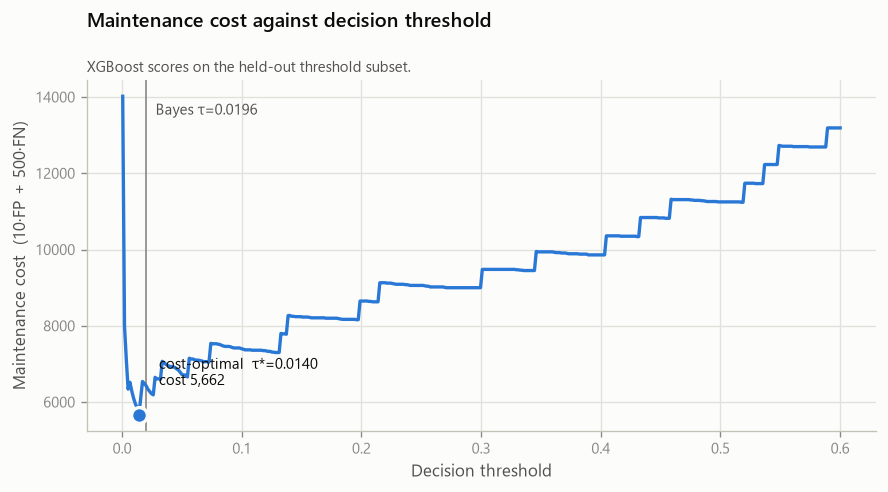

In [3]:
from scania_aps.costs import bayes_threshold, maintenance_cost, optimize_threshold
from scania_aps.plotting import cost_curve

y_threshold = split.y_threshold.to_numpy()
grid = np.linspace(0.0005, 0.60, 400)
curve = np.array(
    [maintenance_cost(y_threshold, (threshold_scores >= t).astype(int)).total_cost
     for t in grid]
)

chosen = optimize_threshold(y_threshold, threshold_scores)

fig, ax = cost_curve(
    grid,
    curve,
    optimal_threshold=chosen.threshold,
    bayes_threshold=bayes_threshold(),
    subtitle="XGBoost scores on the held-out threshold subset.",
)

The curve is steep on the left and shallow on the right. That asymmetry is the
cost ratio made visible: erring towards inspection is cheap, erring towards inaction is
not. The minimum sits far to the left of `0.5`, and the penalty for being slightly too
conservative is much larger than for being slightly too eager.

## What the threshold is worth

The same model, the same scores, three different decision rules.

In [4]:
from scania_aps.metrics import evaluate_scores

y_test = test.y.to_numpy()
rules = {
    "conventional 0.5": 0.5,
    "Bayes threshold": bayes_threshold(),
    "cost-optimal (learned)": chosen.threshold,
}

rows = []
for name, t in rules.items():
    evaluation = evaluate_scores(y_test, test_scores, t, score_kind="probability")
    rows.append(
        {
            "rule": name,
            "threshold": t,
            "false_negatives": evaluation.false_negatives,
            "false_positives": evaluation.false_positives,
            "recall": evaluation.recall,
            "precision": evaluation.precision,
            "total_cost": evaluation.total_cost,
        }
    )

decisions = pd.DataFrame(rows).set_index("rule")
learned_cost = decisions.loc["cost-optimal (learned)", "total_cost"]
saving = 1 - learned_cost / decisions.loc["conventional 0.5", "total_cost"]
print(f"Learned threshold vs 0.5: {saving:.1%} lower cost, on an unchanged model.")
decisions

Learned threshold vs 0.5: 64.3% lower cost, on an unchanged model.


,threshold,false_negatives,false_positives,recall,precision,total_cost
rule,,,,,,
conventional 0.5,0.500000,57,47,0.848000,0.871233,28970.0
Bayes threshold,0.019608,11,424,0.970667,0.461929,9740.0
cost-optimal (learned),0.014009,11,485,0.970667,0.428740,10350.0


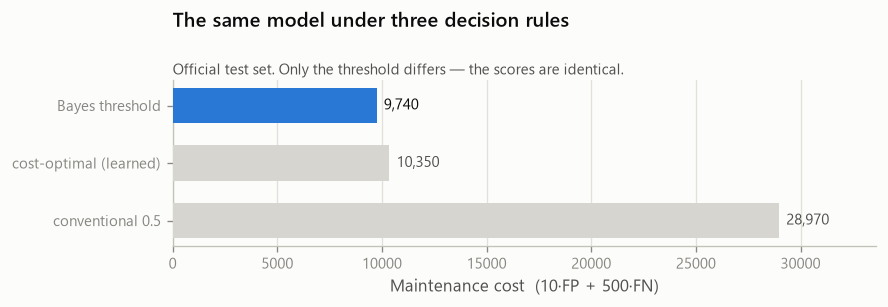

In [5]:
from scania_aps.plotting import emphasis_bars

fig, ax = emphasis_bars(
    list(decisions.index),
    [float(v) for v in decisions["total_cost"].to_numpy()],
    title="The same model under three decision rules",
    subtitle="Official test set. Only the threshold differs — the scores are identical.",
    xlabel="Maintenance cost  (10·FP + 500·FN)",
)

### Reading the result

Look at the `false_negatives` column. At `0.5` the model leaves a large number of
failures uncaught, because a rare-event classifier trained on log loss puts very little
probability mass above `0.5`. Each of those misses costs 500, and they dominate the
bill. Both cost-aware rules trade a few hundred extra inspections at 10 apiece to
recover most of them, and both win by a wide margin.

**This is the headline finding of the study.** The decision rule is not a
postprocessing detail; on this problem it is the single highest-leverage choice
available, and it costs nothing to apply to a model you have already trained.

### A result worth not glossing over

Compare the two cost-aware rules against each other rather than against `0.5`.

The learned threshold is, by construction, the cheapest possible cut **on the threshold
subset**. It does not follow that it is cheapest on the test set, and in this run it is
not — the theoretical Bayes value, which looked at no data at all, generalises slightly
better.

That is not a bug, it is the bias–variance trade applied to a single scalar. The learned
threshold is fitted to 6,000 trucks and inherits their sampling noise; the Bayes value
has no variance because it is derived from the cost ratio alone. When the model's
probabilities are close enough to calibrated for `10/(10+500)` to be roughly right, the
zero-variance estimate can beat the fitted one.

Two things follow. First, the gap between the two is small and well inside what a single
split can resolve — neither should be reported as *the* better rule on this evidence.
Second, calibration and thresholding are not independent choices: the better calibrated
the scores, the more the theoretical threshold is worth, which is the connection back to
[notebook 09](09_probability_calibration.ipynb).

**Next:** [11 — feature selection](11_feature_selection.ipynb).